# Лабораторная работа 8

Тема: **Свёрточные нейросети (CNN) для CIFAR‑10 в PyTorch**  
Цель: построить и исследовать собственную свёрточную сеть для классификации изображений CIFAR‑10, понять, как архитектура и гиперпараметры влияют на качество.

> Этот ноутбук специально оформлен как практическое задание.  
> Код даёт каркас, но **основные баллы** ставятся за ваши эксперименты и ваши тексты.  
> Если вы просто скормите ноутбук генеративной модели и вставите сгенерированные ответы, это будет видно по стилю и несоответствию коду/графикам.


## 1. Ваши ожидания от CNN

Перед началом работы поставьте скачиваться CIFAR‑10 и зафиксируйте своё понимание:

1. Чем, с вашей точки зрения, свёрточная сеть отличается от "обычного" MLP, если объяснять без формул, на интуитивном уровне.  
2. Почему для картинок обычно используют CNN, а не только полносвязные слои.  
3. Какую примерно точность на CIFAR‑10 вы считаете "разумной" для простой самодельной CNN (не топовой).

Пишите 6–10 предложений, на нормальном языке, как если бы объясняли одногруппнику.


In [2]:
intro_text = """ЗДЕСЬ СВОИМИ СЛОВАМИ ОПИШИТЕ, ЧТО ВЫ ЖДЁТЕ ОТ CNN НА CIFAR‑10.
Можно написать, какие свойства архитектуры кажутся вам важными,
и какую точность вы хотели бы увидеть к концу экспериментов.

1. В MLP все нейроны каждого слоя связаны со всеми нейронами предыдущего слоя (от того и название - полносвязные слои).
А в CNN каждый нейрон связан с небольшой областью предыдущего слоя. В целом, это основное отличие их друг от друга.

2. Для картинок обычно используют CNN, потому что он смотрит на отдельные области изображения.
Это помогает легче классифицировать, например, уши, нос, рот и т.п. на лице человека или животного. Повышается итоговая точность.
MLP делать это сложнее, из-за того что он смотрит сразу на всю картинку целиком.

3. Думаю, что для простой самодельной CNN будет достаточно 70% точности (не много, не мало и не стыдно)"""
print(intro_text)

ЗДЕСЬ СВОИМИ СЛОВАМИ ОПИШИТЕ, ЧТО ВЫ ЖДЁТЕ ОТ CNN НА CIFAR‑10.
Можно написать, какие свойства архитектуры кажутся вам важными,
и какую точность вы хотели бы увидеть к концу экспериментов.

1. В MLP все нейроны каждого слоя связаны со всеми нейронами предыдущего слоя (от того и название - полносвязные слои).
А в CNN каждый нейрон связан с небольшой областью предыдущего слоя. В целом, это основное отличие их друг от друга.

2. Для картинок обычно используют CNN, потому что он смотрит на отдельные области изображения.
Это помогает легче классифицировать, например, уши, нос, рот и т.п. на лице человека или животного. Повышается итоговая точность.
MLP делать это сложнее, из-за того что он смотрит сразу на всю картинку целиком.

3. Думаю, что для простой самодельной CNN будет достаточно 70% точности (не много, не мало и не стыдно)


## 2. Импорт библиотек и настройка среды

Сделаем стандартные шаги:
- импорт PyTorch и torchvision;
- настройка отрисовки графиков;
- фиксация seed (выберите число сами);
- определение устройства (`cpu` или `cuda`).


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Ваш личный seed (заполните его)
MY_SEED = 0
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 0


## 3. CIFAR‑10: загрузка, нормализация, первичный просмотр

Загрузим CIFAR‑10 через `torchvision.datasets.CIFAR10`.

Сделаем:
- перевод в тензор (`ToTensor`);
- нормализацию по каналам (можно использовать стандартные значения для CIFAR‑10);
- DataLoader для train и test.


In [54]:
batch_size = 256  # при выполнении работы попробуйте хотя бы ещё одно значение

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = train_dataset.classes
print("Классы CIFAR‑10:", classes)
print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

Классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Размер train: 50000
Размер test : 10000
batch_size = 256


Посмотрим на несколько изображений, чтобы глазами увидеть разнообразие классов и качество картинок.


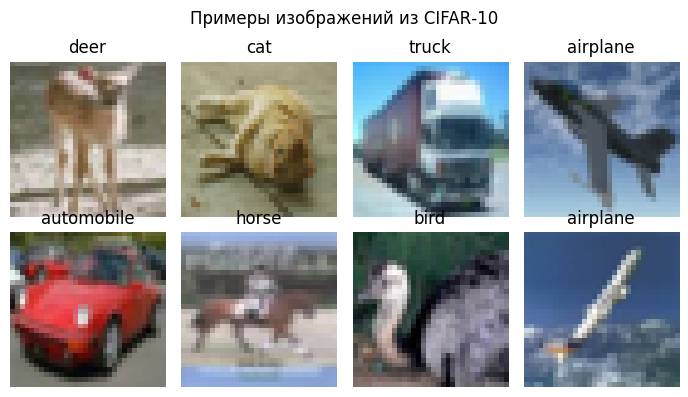

In [3]:
images, labels = next(iter(train_loader))

def denorm(img_tensor):
    # разворачиваем нормализацию для отображения
    img = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = img * std + mean
    return np.clip(img, 0, 1)

plt.figure(figsize=(7, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(denorm(images[i]))
    plt.title(classes[labels[i].item()])
    plt.axis("off")
plt.suptitle("Примеры изображений из CIFAR‑10")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным (заполняется студентом)

Опишите в 3–5 предложениях:
- какие классы по картинкам вам кажутся наиболее сложными для различения;
- есть ли визуальный шум/размытость;
- насколько задача кажется вам сложнее/проще, чем MNIST.


In [ ]:
data_comment = """ЗДЕСЬ КРАТКО ОПИШИТЕ ВАШИ ВПЕЧАТЛЕНИЯ О CIFAR‑10.
Можно упомянуть, какие классы визуально путаются, и сравнить с MNIST.

Наиболее сложными для различия мне кажутся классы bird и dog (не всегда понятно куда соотнести картинки с первого взгляда). Еще есть некоторые темные картинки, например, у airplane, где прямо всматриваться нужно.
Все картинки размыты, но большинство можно классифицировать легко.
Я бы назвал эту задачу и MNIST практически одинаковыми, не могу явно определить что сложнее. Возможно, CIFAR-10 проще, потому что тут картинки цветные, нежели в черно-белом MNIST.
"""
print(data_comment)

## 4. Архитектура CNN (исходный вариант)

В этой лабораторной важно не просто запустить готовый код, а **понимать** свою архитектуру и уметь её менять.

Задайте базовый вариант сети:
- несколько блоков `Conv2d → ReLU → MaxPool2d`;
- один или два полносвязных слоя после свёрток;
- выходной слой с 10 логитами.

Ниже — пример архитектуры. В своей работе вы **обязаны** попробовать хотя бы ещё один вариант (с другим числом каналов/слоёв) и сравнить результаты.


In [ ]:
class SimpleCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_simple = SimpleCIFARCNN(num_classes=len(classes)).to(device)
print(model_simple)

SimpleCIFARCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


### Ваш комментарий к архитектуре

Ответьте коротко:
- почему вы считаете, что такого размера/глубины сети **должно** быть примерно достаточно для CIFAR‑10 (или, наоборот, нет);
- какие альтернативы вы планируете попробовать (например, другой размер фильтров, дополнительные свёрточные слои, Dropout).


In [ ]:
arch_comment = """ЗДЕСЬ КРАТКО ОПИШИТЕ, ПОЧЕМУ ВЫ ОСТАНОВИЛИСЬ НА ТАКОЙ АРХИТЕКТУРЕ
И КАКИЕ ВАРИАНТЫ ПЛАНИРУЕТЕ ИСПРОБОВАТЬ ДОПОЛНИТЕЛЬНО.

Я считаю, что изначального размера сети должно быть достаточно для CIFAR-10, потому что картинки сами по себе небольшие, много признаков делать в свёртке смысла не вижу.
В качестве альтернативы хочу добавить регуляризацию (Dropout) в полносвязных слоях и BatchNorm в свертке."""
print(arch_comment)

## 5. Функция потерь, оптимизатор и общий цикл обучения

Используем:
- `CrossEntropyLoss` для многоклассовой классификации;
- один из оптимизаторов (`SGD`, `Adam` и т.п.) с выбранным `learning_rate`.

В ходе работы вы должны попробовать хотя бы одну альтернативную настройку (другой `lr` и/или другой оптимизатор) и сравнить с базовой.


In [ ]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model_simple.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


In [4]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Обучение базовой модели

Запустим обучение на несколько эпох, сохраняя историю loss/accuracy.

Рекомендуется:
- начать с небольшого числа эпох (например, 5–8);
- затем увеличить и посмотреть, появляется ли переобучение.


In [ ]:
num_epochs = 10  # попробуйте изменить и сравнить результаты

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model_simple, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model_simple, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")
    
### Эпоха 5/5: train_loss=0.7136, train_acc=0.7496, test_loss=0.8441, test_acc=0.7112
### Эпоха 10/10: train_loss=0.1353, train_acc=0.9544, test_loss=1.0599, test_acc=0.7581

Эпоха 1/10: train_loss=0.6388, train_acc=0.7779, test_loss=0.7877, test_acc=0.7339
Эпоха 2/10: train_loss=0.5615, train_acc=0.8040, test_loss=0.7754, test_acc=0.7395
Эпоха 3/10: train_loss=0.5003, train_acc=0.8250, test_loss=0.7190, test_acc=0.7594
Эпоха 4/10: train_loss=0.4363, train_acc=0.8478, test_loss=0.7458, test_acc=0.7544
Эпоха 5/10: train_loss=0.3731, train_acc=0.8704, test_loss=0.8106, test_acc=0.7442
Эпоха 6/10: train_loss=0.3195, train_acc=0.8888, test_loss=0.7926, test_acc=0.7556
Эпоха 7/10: train_loss=0.2612, train_acc=0.9102, test_loss=0.8495, test_acc=0.7546
Эпоха 8/10: train_loss=0.2119, train_acc=0.9268, test_loss=0.9216, test_acc=0.7526
Эпоха 9/10: train_loss=0.1740, train_acc=0.9410, test_loss=0.9300, test_acc=0.7591
Эпоха 10/10: train_loss=0.1353, train_acc=0.9544, test_loss=1.0599, test_acc=0.7581


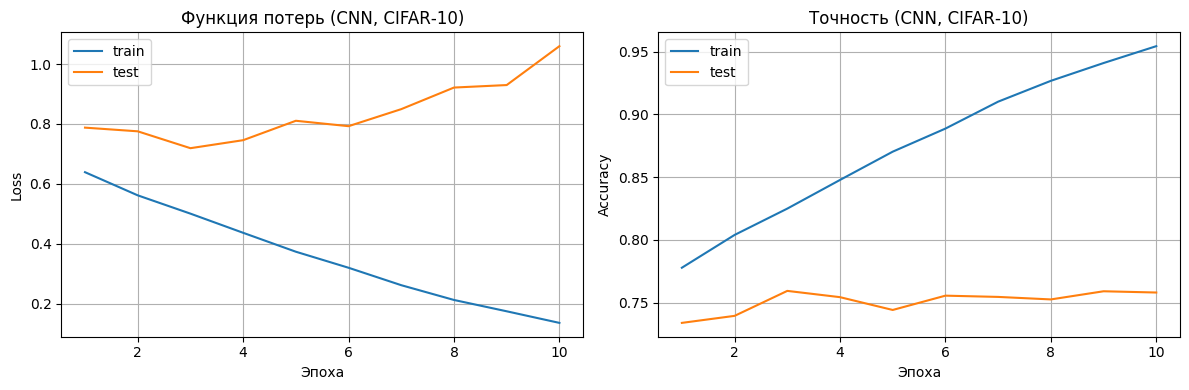

Финальная точность: train=0.9544, test=0.7581


In [23]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (CNN, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (CNN, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

### Анализ кривых обучения (заполняется студентом)

Опишите в 6–8 предложениях:
- как ведут себя train/test loss (сходятся ли, расходятся ли);
- есть ли заметный разрыв между train и test accuracy;
- кажется ли вам, что модель уже переобучилась или ещё недообучена;
- какие изменения (архитектуры, lr, числа эпох) вы бы попробовали дальше.


In [ ]:
training_analysis = """ЗДЕСЬ ОПИШИТЕ, ЧТО ВЫ УВИДЕЛИ НА ГРАФИКАХ.
Сошлитесь на конкретные значения train/test accuracy и сделайте выводы
про переобучение/недообучение и возможные next steps.

train/test loss расходятся. На 10 эпохах есть заметный разрыв accuracy (train_acc=0.9544, test_acc=0.7581) и заметно переобучение (train_loss=0.1353, test_loss=1.0599) (очень большой разрыв loss).
Дальше я бы попробовал 25 и 50 эпох и добавил регуляризацию."""
print(training_analysis)

## 7. Примеры правильных и неправильных предсказаний

Посмотрим на несколько изображений, которые модель классифицирует верно и неверно, чтобы понять, где ей сложнее всего.


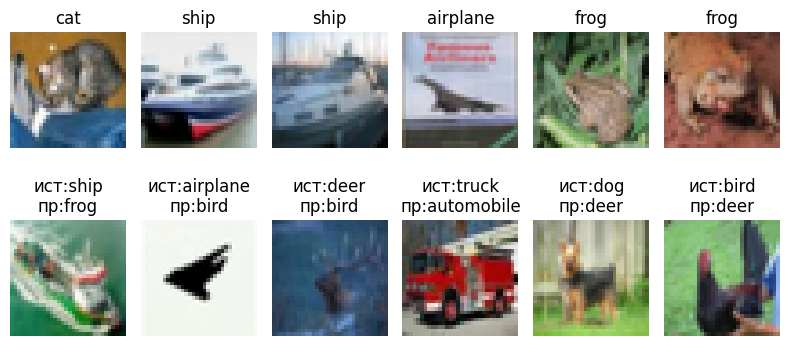

In [ ]:
model_simple.eval()
correct_imgs, correct_true, correct_pred = [], [], []
wrong_imgs, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_simple(images)
        preds = outputs.argmax(dim=1)

        for img, lab, pr in zip(images, labels, preds):
            if lab == pr and len(correct_imgs) < 6:
                correct_imgs.append(img.cpu())
                correct_true.append(lab.cpu().item())
                correct_pred.append(pr.cpu().item())
            if lab != pr and len(wrong_imgs) < 6:
                wrong_imgs.append(img.cpu())
                wrong_true.append(lab.cpu().item())
                wrong_pred.append(pr.cpu().item())
        if len(correct_imgs) >= 6 and len(wrong_imgs) >= 6:
            break

plt.figure(figsize=(8, 4))
for i in range(len(correct_imgs)):
    plt.subplot(2, 6, i + 1)
    plt.imshow(denorm(correct_imgs[i]))
    plt.title(classes[correct_true[i]])
    plt.axis("off")
for i in range(len(wrong_imgs)):
    plt.subplot(2, 6, 6 + i + 1)
    plt.imshow(denorm(wrong_imgs[i]))
    true_label = classes[wrong_true[i]]
    pred_label = classes[wrong_pred[i]]
    plt.title(f"ист:{true_label}\nпр:{pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Комментарий по ошибкам

Ответьте кратко:
- какие пары классов чаще всего путаются в ваших примерах;
- выглядят ли эти ошибки "человечески понятными" или, наоборот, странными;
- есть ли примеры, где вы сами сомневались бы в правильном классе.


In [ ]:
errors_comment = """ЗДЕСЬ ОПИШИТЕ НЕСКОЛЬКО НАБЛЮДЕНИЙ О ТОМ, ЧТО МОДЕЛЬ ПУТАЕТ.
Укажите хотя бы 1–2 пары классов, которые чаще всего перепутаны
в ваших примерах.

Чаще всего модель путает классы bird с чем-то другим (в особенности с airplane и deer).
Многие ошибки человечески понятны, но есть, например, некоторые примеры airplane, где реально сложно определить самолет это или птица."""
print(errors_comment)

## 8. Эксперименты по улучшению модели

В **самостоятельной** части лабораторной вы должны будете:
- изменить архитектуру (добавить/убрать слой, поменять число каналов, добавить Dropout/BatchNorm);
- изменить настройки обучения (другой оптимизатор, lr, число эпох);
- сравнить **минимум два** варианта модели по test accuracy и кривым обучения.

Здесь не приводится готовый код, чтобы не превращать задание в копирование. Используйте функции и блоки выше как строительные кирпичики.


In [ ]:
class UpdatedCIFARCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout_rate),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout_rate),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout_rate)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_updated = UpdatedCIFARCNN(num_classes=len(classes)).to(device)
print(model_updated)

UpdatedCIFARCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.3, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2d(p=0.

In [85]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-2
# optimizer = torch.optim.Adam(model_updated.parameters(), lr=learning_rate)

momentum = 0.9
weight_decay = 5e-4
optimizer = torch.optim.SGD(
    model_updated.parameters(),
    lr=learning_rate,
    momentum=momentum,
    weight_decay=weight_decay
)


print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.0005
)
learning_rate = 0.01


In [86]:
num_epochs = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model_updated, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model_updated, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Эпоха 1/10: train_loss=0.6441, train_acc=0.7714, test_loss=0.6447, test_acc=0.7745
Эпоха 2/10: train_loss=0.6383, train_acc=0.7733, test_loss=0.6483, test_acc=0.7742
Эпоха 3/10: train_loss=0.6379, train_acc=0.7758, test_loss=0.6423, test_acc=0.7748
Эпоха 4/10: train_loss=0.6335, train_acc=0.7763, test_loss=0.6431, test_acc=0.7754
Эпоха 5/10: train_loss=0.6390, train_acc=0.7742, test_loss=0.6455, test_acc=0.7747
Эпоха 6/10: train_loss=0.6290, train_acc=0.7781, test_loss=0.6331, test_acc=0.7798
Эпоха 7/10: train_loss=0.6288, train_acc=0.7768, test_loss=0.6344, test_acc=0.7794
Эпоха 8/10: train_loss=0.6298, train_acc=0.7776, test_loss=0.6303, test_acc=0.7827
Эпоха 9/10: train_loss=0.6230, train_acc=0.7803, test_loss=0.6291, test_acc=0.7808
Эпоха 10/10: train_loss=0.6220, train_acc=0.7812, test_loss=0.6285, test_acc=0.7781


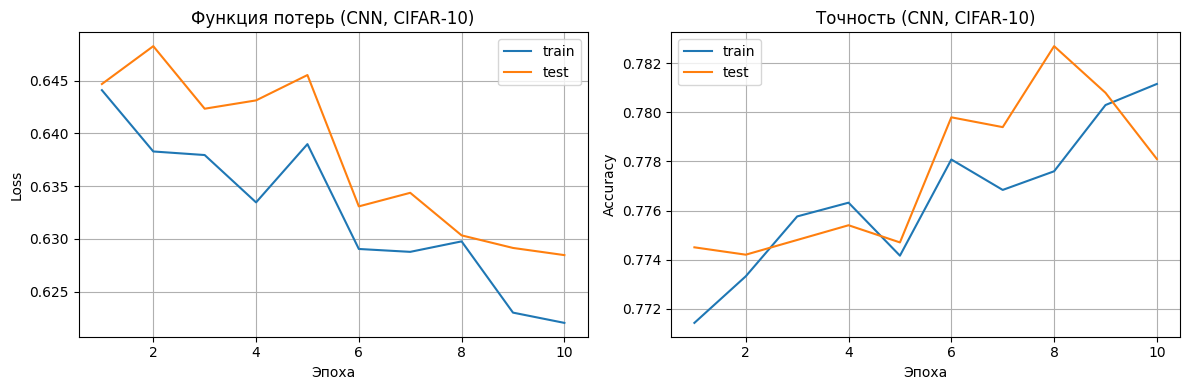

Финальная точность: train=0.7812, test=0.7781


In [87]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (CNN, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (CNN, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

## 9. Итоговые выводы по лабораторной

В конце опишите:
- до какой тестовой точности вы дошли для разных вариантов моделей и при каких настройках;
- какие изменения архитектуры/гиперпараметров дали наибольший эффект;
- что для вас стало главным практическим выводом о работе CNN на CIFAR‑10 (например, чувствительность к lr, важность аугментаций, глубина сети и т.п.).

Пишите 10–15 предложений, ссылаясь на **свои** эксперименты, а не на теорию из интернета.


In [ ]:
final_summary = """ЗДЕСЬ НАПИШИТЕ ИТОГОВЫЙ ТЕКСТ ПО ЛАБОРАТОРНОЙ.
Упомяните конкретные цифры (test accuracy для разных моделей),
и сформулируйте свои личные правила: какую CNN и с какими настройками
вы бы стали пробовать первой в новой задаче, похожей на CIFAR‑10.

Пробовал сначала просто увеличить количество полносвязных слоёв с Dropout от 0.3 до 0.5 - всё плохо, лучшая итоговая точность test_acc=0.1050.
Дальше пытался сделать без Dropout, но добавил BatchNorm также в полносвязные слои - тут практически не изменилось (test_acc=0.1054).
Увеличил количество признаков: 128*4*4 -> 512 -> 10, и все же добавил Dropout (оставил на 0.3) - хуже, test_acc=0.0790.
Настройка в сверточных слоях уже дала свой результат. Добавил туда по одному слою в каждый блок, Dropout (0.3) и BatchNorm - test_acc=0.7605.
Это вместо Adam lr=0.001 (отработал лучше на этом lr), поставил SGD+mom - test_acc=0.7761. Да, лучше, но были признаки переобучения.

Еще в конце концов (посмотрел в Интернете, честно) добавил weight_decay=5е-4 в SGD - точность выросла (test_acc=0.7827), но график стал не очень стабильным.

Это краткое содержание моего тестирования. В основном тестировал на 10 эпохах, показывало результат лучше, чем на 5-8.
Стоит упомянуть, что итоговый вариант модели работает долго, каждая эпоха занимает по 17-18 секунд.
Менял batch_size на 1024 и 256, с первым работает быстрее, но все же я оставил 256.

Исходя из тестирования, можно точно сказать, что в CNN важна глубина и обработка именно сверточной сети и она чувствительна к lr.


P.s. Заметил, что на одних и тех же гиперпараметрах модель может работать по-разному. Например, на Adam lr=0.001 может быть точность 0.1018 и 0.7761.
Но когда меняешь параметры на другие, запускаешь, а потом опять меняешь на предыдущие и запускаешь, то все нормализуется.
Может я что-то неправильно делаю? Мне кажется, так не должно быть.

лучшая точность - test_acc=0.8194 на Adam lr=0.001"""
print(final_summary)